## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import re
import time
import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")
np.random.seed(RANDOM_STATE)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Dataset
Dataset used: AG News Classification Dataset (Kaggle): https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset. This is the standard AG News corpus (the same corpus referenced in the Zhang, Zhao & LeCun paper, Section 4, "AG's news corpus"), packaged by Kaggle user amananandrai as ready-to-use train.csv and test.csv files.

In [13]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# The Kaggle release ships with a header row and these exact column names
train.columns = ["class_index", "title", "description"]
test.columns = ["class_index", "title", "description"]

LABEL_MAP = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

train["text"] = train["title"] + " " + train["description"]
test["text"] = test["title"] + " " + test["description"]
train["topic"] = train["class_index"].map(LABEL_MAP)
test["topic"] = test["class_index"].map(LABEL_MAP)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (120000, 5)
Test shape: (7600, 5)


In [14]:
train.head()

,class_index,title,description,text,topic
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new...",Business


## 3. Exploratory Data Analysis (EDA)

In [15]:

print("Column names:", list(train.columns))
print()
print("Data types:")
print(train.dtypes)

Column names: ['class_index', 'title', 'description', 'text', 'topic']

Data types:
class_index     int64
title          object
description    object
text           object
topic          object
dtype: object


In [16]:
print("Missing values per column:")
print(train.isnull().sum())
print()
print("Duplicate rows:", train.duplicated().sum())

Missing values per column:
class_index    0
title          0
description    0
text           0
topic          0
dtype: int64

Duplicate rows: 0


In [17]:
print("Number of classes:", train['class_index'].nunique())
print()
print("Class distribution (train):")
print(train['topic'].value_counts())
print()
print("Class distribution (test):")
print(test['topic'].value_counts())

Number of classes: 4

Class distribution (train):
topic
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Class distribution (test):
topic
Business    1900
Sci/Tech    1900
Sports      1900
World       1900
Name: count, dtype: int64


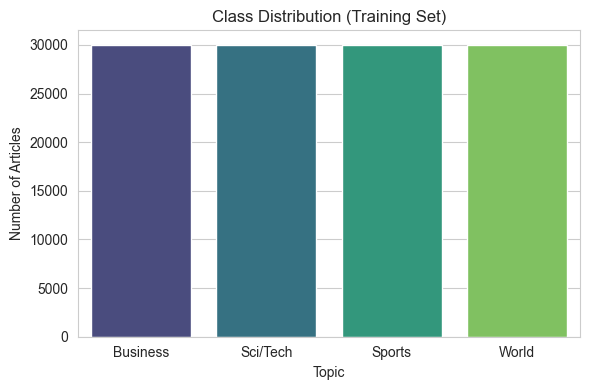

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x="topic", hue="topic",
              order=train['topic'].value_counts().index,
              palette="viridis", legend=False)
plt.title("Class Distribution (Training Set)")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

The class distribution bar chart confirms the dataset is perfectly balanced (30,000 articles per class). This is important: it means plain accuracy is a fair metric here, and we don't need class-weighting or resampling techniques that would be necessary for an imbalanced dataset.

In [19]:
train["text_len"] = train["text"].apply(lambda x: len(str(x).split()))
print(train["text_len"].describe())

count    120000.000000
mean         37.844617
std          10.088702
min           4.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_len, dtype: float64


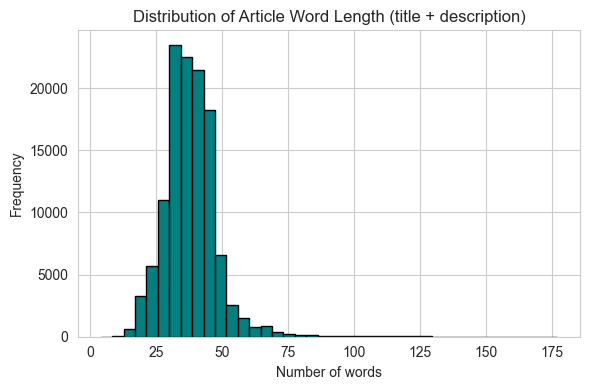

In [20]:
plt.figure(figsize=(6,4))
plt.hist(train['text_len'], bins=40, color="teal", edgecolor="black")
plt.title("Distribution of Article Word Length (title + description)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Text Preprocessing
We define a single clean_text() function applying, in order: lowercasing, HTML-tag removal, URL removal, punctuation/special-character removal, whitespace normalization, tokenization (via .split()), stop-word removal, and lemmatization. The exact same function is reused later at prediction time, so training and inference are guaranteed to be consistent.

In [21]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                          # 1. lowercase
    text = re.sub(r"<.*?>", " ", text)                 # 2. remove HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)     # 3. remove URLs
    text = text.replace("\\", " ")                    # AG News uses literal backslashes as line breaks
    text = re.sub(r"[^a-z0-9\s]", " ", text)           # 4. remove punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()           # 5. normalize whitespace
    tokens = text.split()                              # 6. tokenize
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]  # 7. remove stop words
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # 8. lemmatize
    return " ".join(tokens)

# quick demonstration on one example
sample_raw = train["text"].iloc[0]
print("RAW:  ", sample_raw)
print("CLEAN:", clean_text(sample_raw))

RAW:   Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
CLEAN: wall st bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green


In [22]:
t0 = time.time()
train["clean_text"] = train["text"].apply(clean_text)
test["clean_text"] = test["text"].apply(clean_text)
print(f"Preprocessing completed in {time.time() - t0:.1f} seconds for {len(train)+len(test)} articles.")

train["clean_len"] = train["clean_text"].apply(lambda x: len(x.split()))
print("\nAverage word count before cleaning:", round(train['text_len'].mean(), 2))
print("Average word count after cleaning: ", round(train['clean_len'].mean(), 2))

Preprocessing completed in 24.0 seconds for 127600 articles.

Average word count before cleaning: 37.84
Average word count after cleaning:  26.45


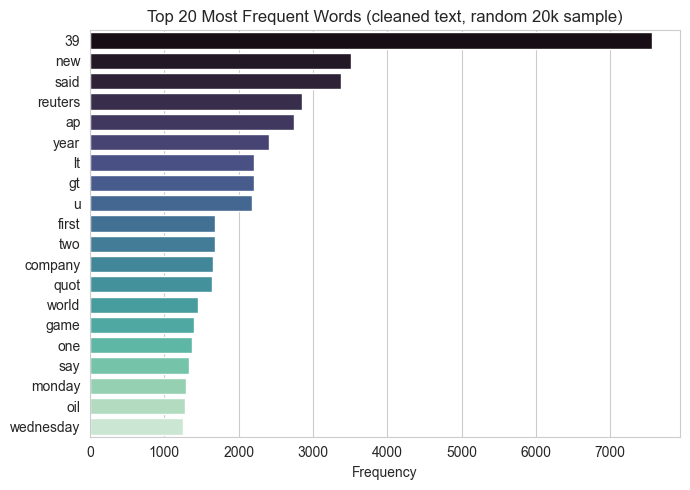

In [23]:
from collections import Counter
all_words = " ".join(train['clean_text'].sample(20000, random_state=RANDOM_STATE)).split()
top20 = Counter(all_words).most_common(20)
words, freqs = zip(*top20)

plt.figure(figsize=(7,5))
sns.barplot(x=list(freqs), y=list(words), hue=list(words), palette="mako", legend=False)
plt.title("Top 20 Most Frequent Words (cleaned text, random 20k sample)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Train/Test Split

In [24]:
X_train_text, y_train = train["clean_text"], train["class_index"]
X_test_text, y_test = test["clean_text"], test["class_index"]
print("Training samples:", len(X_train_text))
print("Testing samples: ", len(X_test_text))

Training samples: 120000
Testing samples:  7600


## 6. Feature Extraction - TF-IDF


In [25]:
vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                              min_df=3, max_df=0.9, sublinear_tf=True)

X_train = vectorizer.fit_transform(X_train_text)   # fit + transform on TRAIN only
X_test = vectorizer.transform(X_test_text)          # transform ONLY on TEST (no leakage)

print("TF-IDF training matrix shape:", X_train.shape)
print("TF-IDF testing matrix shape: ", X_test.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

TF-IDF training matrix shape: (120000, 30000)
TF-IDF testing matrix shape:  (7600, 30000)
Vocabulary size: 30000


## 7. Model Training

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
}

results = {}
preds_store = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    preds = model.predict(X_test)
    preds_store[name] = preds

    acc = accuracy_score(y_test, preds)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_test, preds, average="macro")
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_test, preds, average="weighted")

    results[name] = {
        "accuracy": acc,
        "precision_macro": p_m, "recall_macro": r_m, "f1_macro": f1_m,
        "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w,
        "train_time_sec": train_time,
    }
    print(f"{name:28s} | accuracy={acc:.4f} | f1_macro={f1_m:.4f} | train_time={train_time:.2f}s")

Logistic Regression          | accuracy=0.9220 | f1_macro=0.9218 | train_time=9.82s
Multinomial Naive Bayes      | accuracy=0.9037 | f1_macro=0.9033 | train_time=0.07s
Linear SVM                   | accuracy=0.9204 | f1_macro=0.9203 | train_time=6.48s


## 8. Model Evaluation


In [27]:
labels_order = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
for name in models:
    print("="*70)
    print(name)
    print("="*70)
    print(classification_report(y_test, preds_store[name], target_names=labels_order, digits=4))

Logistic Regression
              precision    recall  f1-score   support

       World     0.9377    0.9111    0.9242      1900
      Sports     0.9574    0.9821    0.9696      1900
    Business     0.8921    0.8921    0.8921      1900
    Sci/Tech     0.9003    0.9026    0.9014      1900

    accuracy                         0.9220      7600
   macro avg     0.9219    0.9220    0.9218      7600
weighted avg     0.9219    0.9220    0.9218      7600

Multinomial Naive Bayes
              precision    recall  f1-score   support

       World     0.9164    0.8947    0.9055      1900
      Sports     0.9457    0.9800    0.9625      1900
    Business     0.8802    0.8505    0.8651      1900
    Sci/Tech     0.8711    0.8895    0.8802      1900

    accuracy                         0.9037      7600
   macro avg     0.9034    0.9037    0.9033      7600
weighted avg     0.9034    0.9037    0.9033      7600

Linear SVM
              precision    recall  f1-score   support

       World     0.9

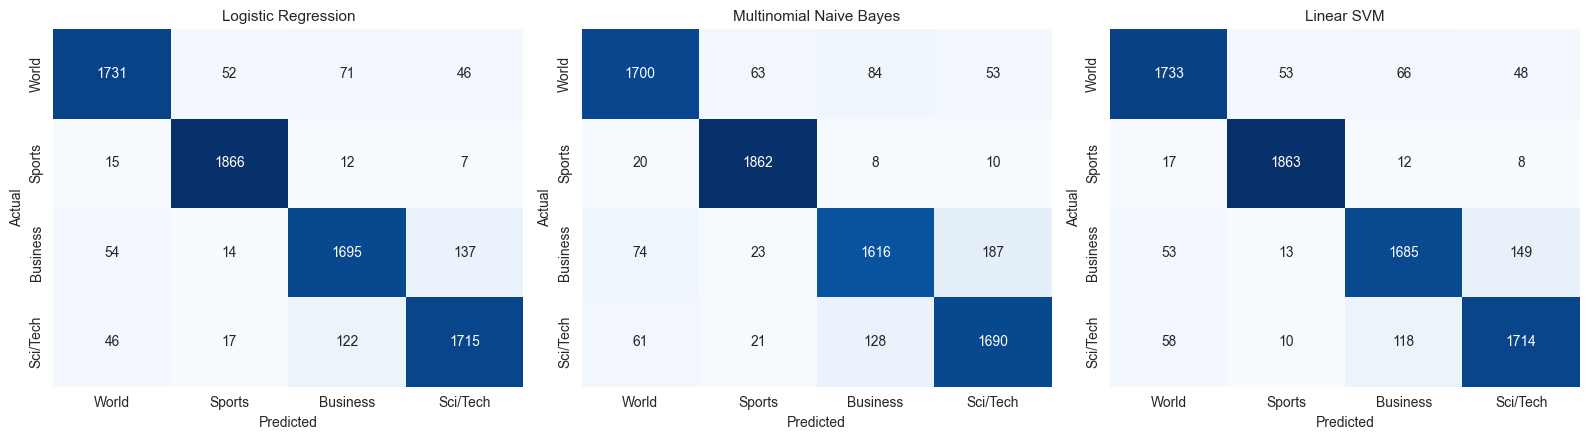

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds_store[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_order, yticklabels=labels_order, ax=ax, cbar=False)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Model Comparison

In [29]:
results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy","precision_macro","recall_macro","f1_macro",
                          "precision_weighted","recall_weighted","f1_weighted","train_time_sec"]]
results_df.round(4)

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,train_time_sec
Logistic Regression,0.9220,0.9219,0.9220,0.9218,0.9219,0.9220,0.9218,9.8213
Multinomial Naive Bayes,0.9037,0.9034,0.9037,0.9033,0.9034,0.9037,0.9033,0.0730
Linear SVM,0.9204,0.9202,0.9204,0.9203,0.9202,0.9204,0.9203,6.4808


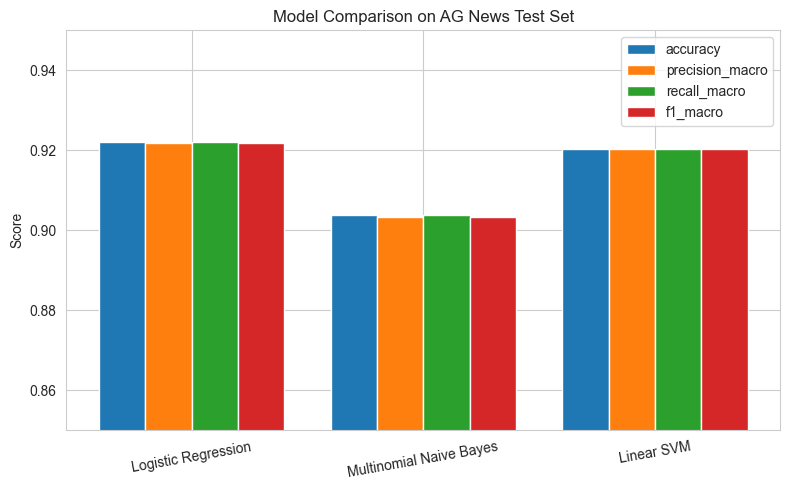

In [30]:
metrics_to_plot = ["accuracy","precision_macro","recall_macro","f1_macro"]
x = np.arange(len(models))
width = 0.2
plt.figure(figsize=(8,5))
for i, m in enumerate(metrics_to_plot):
    vals = [results[mod][m] for mod in models]
    plt.bar(x + i*width, vals, width, label=m)
plt.xticks(x + width*1.5, list(models.keys()), rotation=10)
plt.ylim(0.85, 0.95)
plt.ylabel("Score")
plt.title("Model Comparison on AG News Test Set")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Error Analysis

We inspect articles that were misclassified by the (tuned) Logistic Regression model — see Section 13 for tuning — to understand *why* errors happen, not just how many there are.


In [31]:
best_preds_preview = preds_store["Logistic Regression"]
test_preview = test.copy()
test_preview["pred"] = best_preds_preview
test_preview["pred_topic"] = test_preview["pred"].map(LABEL_MAP)
errors_preview = test_preview[test_preview["class_index"] != test_preview["pred"]]
print(f"Misclassified: {len(errors_preview)} / {len(test_preview)}  (error rate = {len(errors_preview)/len(test_preview):.2%})")

pd.set_option('display.max_colwidth', 140)
errors_preview.sample(8, random_state=RANDOM_STATE)[["text","topic","pred_topic"]]

Misclassified: 593 / 7600  (error rate = 7.80%)


,text,topic,pred_topic
344,"Glory Comes Amid Empty Seats and Closed Shutters HERE in Old Europe, people install shutters outside their windows to keep out the heat,...",Sports,Sci/Tech
789,Bea Arthur for President Bea Arthur sparked a security scare at Logan Airport in Boston this week when she tried to board a Cape Air fli...,Sci/Tech,World
2750,"New \$50 bill designed to counter counterfeits WASHINGTON - The green is still there, but with touches of blue, red and yellow. A styliz...",Business,Sci/Tech
5244,South Korea planning huge spending to revive economy: report (AFP) AFP - The South Korean government is preparing a huge quot;New Deal ...,Business,World
2219,Senate Panel Gives NASA Extra Money (AP) AP - NASA would get #36;16.4 billion next year under a bill a Senate committee approved Tuesda...,World,Sci/Tech
4319,"Avis blames IT for multimillion-dollar loss The car rental company takes a major hit because of problems with IT, including high costs a...",Sci/Tech,Business
3600,"Another Oracle exec says company might lower offer price for &lt;b&gt;...&lt;/b&gt; WILMINGTON, Del. Another Oracle executive says the c...",Business,Sci/Tech
6914,"BBC 'must keep up' BBC boss Mark Thompson says the corporation must keep up with change, after announcing nearly 3,000 job cuts.",World,Business


## 11. Hyperparameter Tuning

In [32]:
sample_idx = train.sample(n=30000, random_state=RANDOM_STATE).index
X_sub = vectorizer.transform(train.loc[sample_idx, "clean_text"])
y_sub = train.loc[sample_idx, "class_index"]

param_grid = {"C": [0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                     param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
grid.fit(X_sub, y_sub)

for params, score in zip(grid.cv_results_["params"], grid.cv_results_["mean_test_score"]):
    print(params, "-> mean CV f1_macro =", round(score, 4))
print("\nBest hyperparameters:", grid.best_params_)

{'C': 0.1} -> mean CV f1_macro = 0.8909
{'C': 1} -> mean CV f1_macro = 0.9056
{'C': 10} -> mean CV f1_macro = 0.9032

Best hyperparameters: {'C': 1}


In [33]:
best_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=grid.best_params_["C"])
best_lr.fit(X_train, y_train)
best_preds = best_lr.predict(X_test)
best_acc = accuracy_score(y_test, best_preds)
print(f"Tuned Logistic Regression (C={grid.best_params_['C']}) test accuracy: {best_acc:.4f}")

Tuned Logistic Regression (C=1) test accuracy: 0.9220


## 14. Saving the Model

In [34]:
joblib.dump(best_lr, "best_model_logreg.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
print("Saved: best_model_logreg.joblib, tfidf_vectorizer.joblib")

Saved: best_model_logreg.joblib, tfidf_vectorizer.joblib


## 15. Prediction System


In [35]:
def predict_topic(article_text, model=best_lr, vec=vectorizer):
    cleaned = clean_text(article_text)
    features = vec.transform([cleaned])
    pred_label = model.predict(features)[0]
    pred_topic = LABEL_MAP[pred_label]

    result = {"predicted_topic": pred_topic}
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(features)[0]
        confidence = proba[model.classes_.tolist().index(pred_label)]
        result["confidence"] = round(float(confidence), 4)
        result["all_class_probabilities"] = {LABEL_MAP[c]: round(float(p), 4)
                                              for c, p in zip(model.classes_, proba)}
    return result

# Demonstration
sample_article = "Apple announced a new generation of processors for its laptop lineup, promising faster performance and better battery life."
print("Input article:")
print(sample_article)
print()
result = predict_topic(sample_article)
print("Predicted Topic:", result["predicted_topic"])
print("Confidence:", result["confidence"])
print("All class probabilities:", result["all_class_probabilities"])

Input article:
Apple announced a new generation of processors for its laptop lineup, promising faster performance and better battery life.

Predicted Topic: Sci/Tech
Confidence: 0.9787
All class probabilities: {'World': 0.0061, 'Sports': 0.0043, 'Business': 0.0109, 'Sci/Tech': 0.9787}
